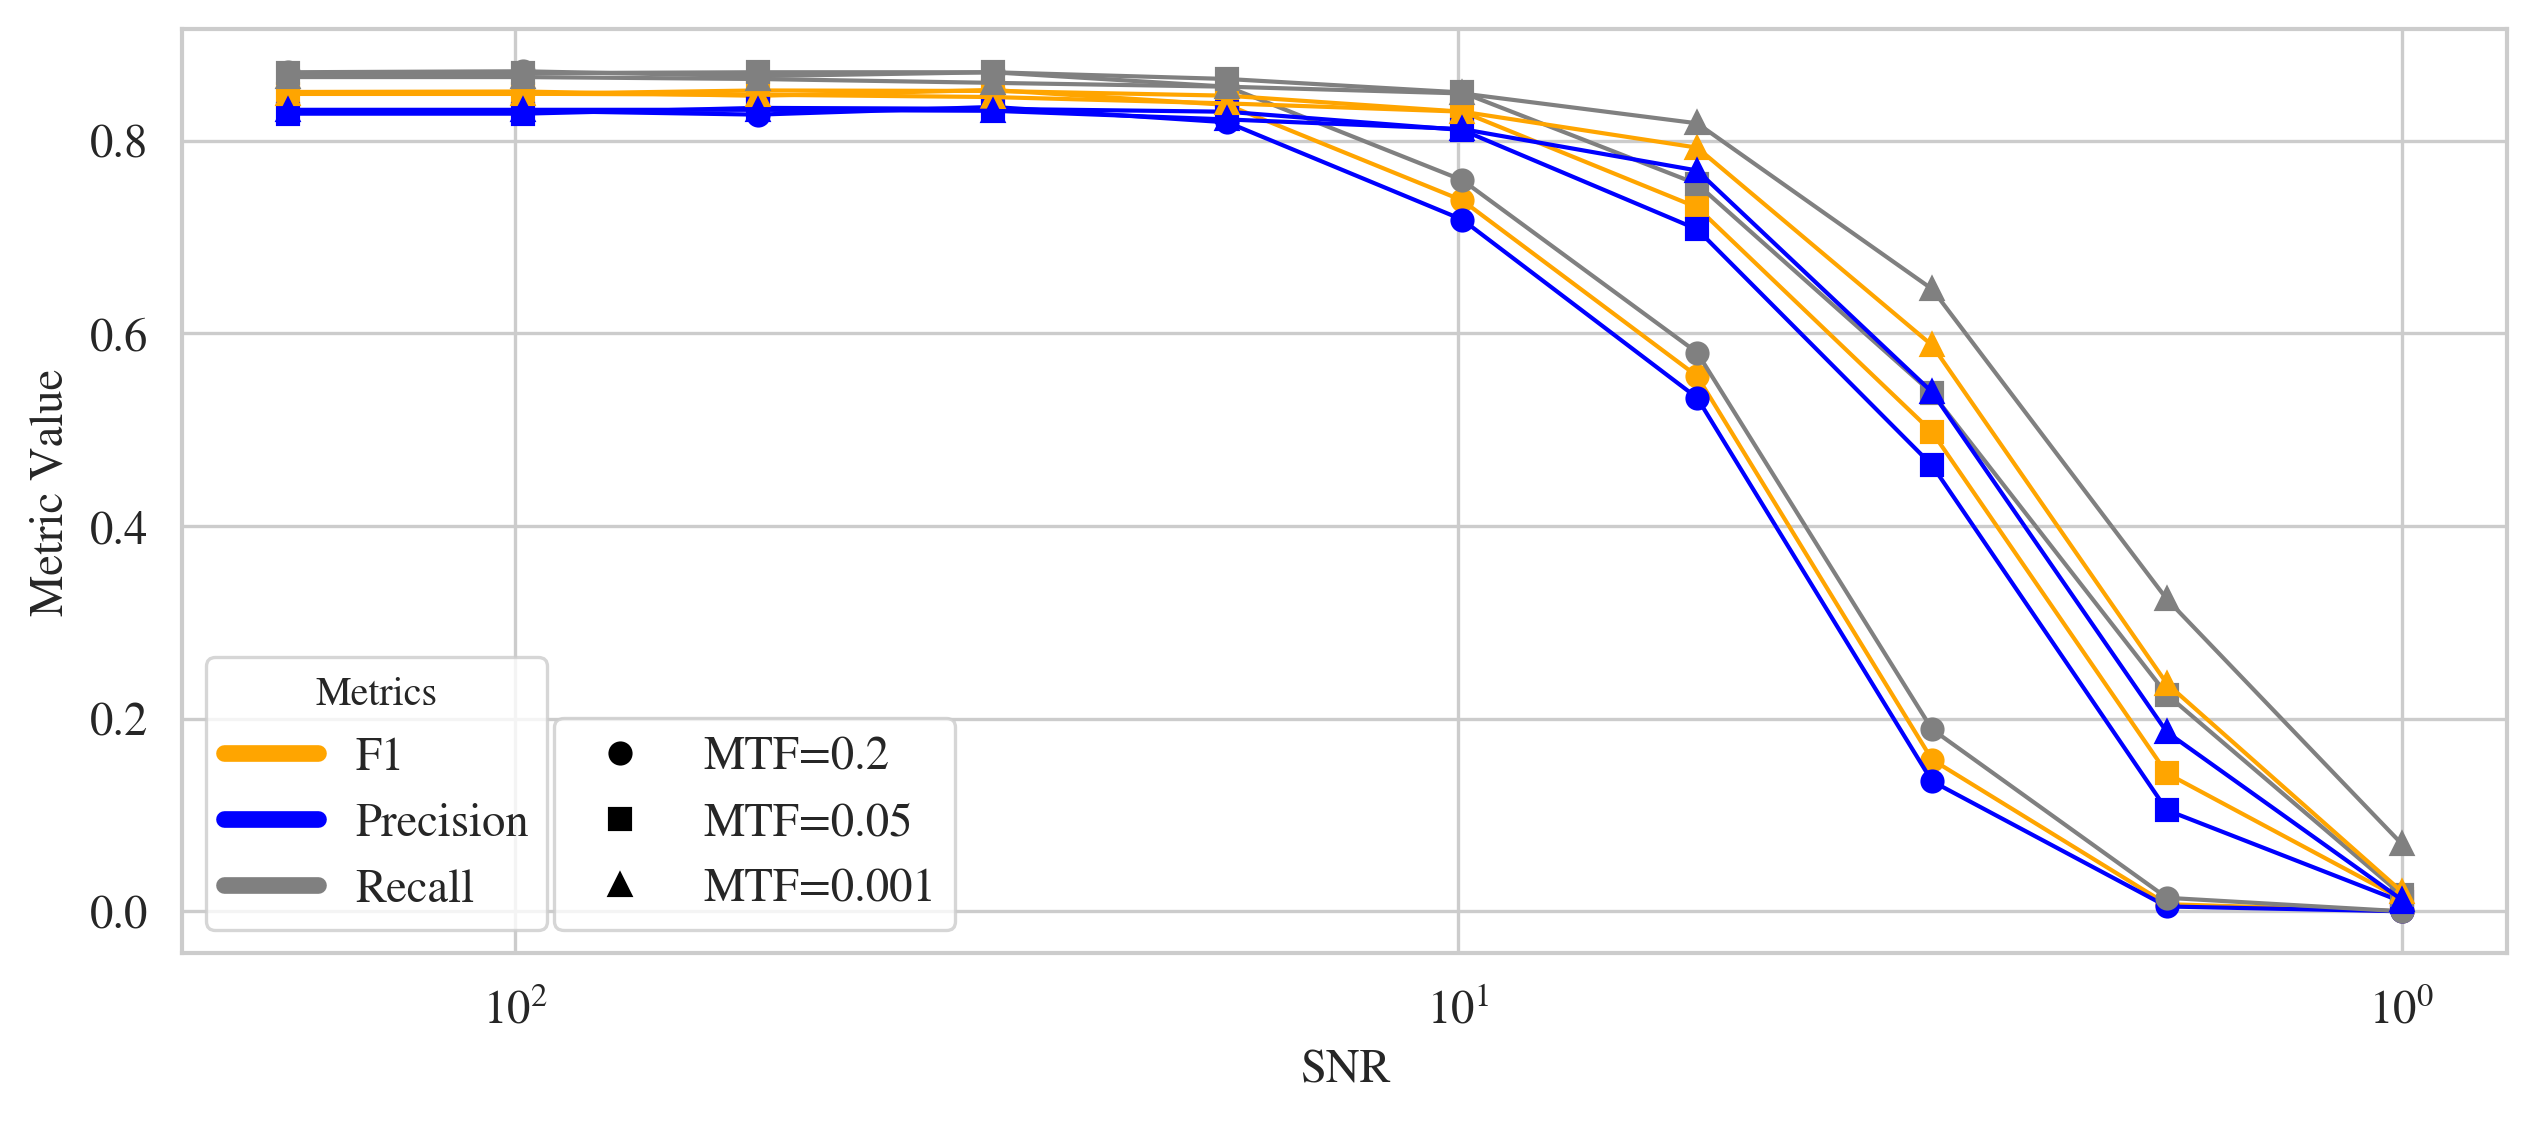

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Read data
df_sen = pd.read_pickle('/Data_large/marine/PythonProjects/MMDET/studies/degradationStudy/sentinel_SNR_study_b8.pkl')
df_ven = pd.read_pickle('/Data_large/marine/PythonProjects/MMDET/studies/degradationStudy/venus_SNR_study_b10.pkl')

# Prepare colors and markers
metrics = ['F1', 'Precision', 'Recall']
colors = {'F1': 'orange', 'Precision': 'blue', 'Recall': 'gray'}

mtf_values = df_ven['MTF'].unique()
markers = ['o', 's', '^']  # Choose markers for each MTF
mtf_to_marker = dict(zip(mtf_values, markers))

# Plot
plt.figure(figsize=(10, 4), dpi=300)

for mtf in mtf_values:
    subset = df_ven[df_ven['MTF'] == mtf]
    for metric in metrics:
        plt.plot(subset['SNR'], subset[metric],
                 color=colors[metric],
                 marker=mtf_to_marker[mtf],
                 linestyle='-',
                 linewidth=1,
                 label=None)

plt.xlabel('SNR')
plt.ylabel('Metric Value')
plt.xscale('log')
plt.gca().invert_xaxis()
plt.grid(True)

# Create legend handles for metrics (colors)
metric_legend_handles = [Line2D([0], [0], color=colors[metric], lw=4) for metric in metrics]
metric_legend_labels = metrics

# Create legend handles for MTF values (markers)
mtf_legend_handles = [Line2D([0], [0], color='black', marker=mtf_to_marker[mtf], linestyle='None') for mtf in mtf_values]
mtf_legend_labels = [f'MTF={mtf}' for mtf in mtf_values]

# Add legends
ax = plt.gca()

legend1 = ax.legend(handles=metric_legend_handles, labels=metric_legend_labels, title='Metrics', loc='lower left')
legend2 = ax.legend(handles=mtf_legend_handles, labels=mtf_legend_labels, title='', loc='lower left', bbox_to_anchor=(0.15, 0))

ax.add_artist(legend1)

plt.show()





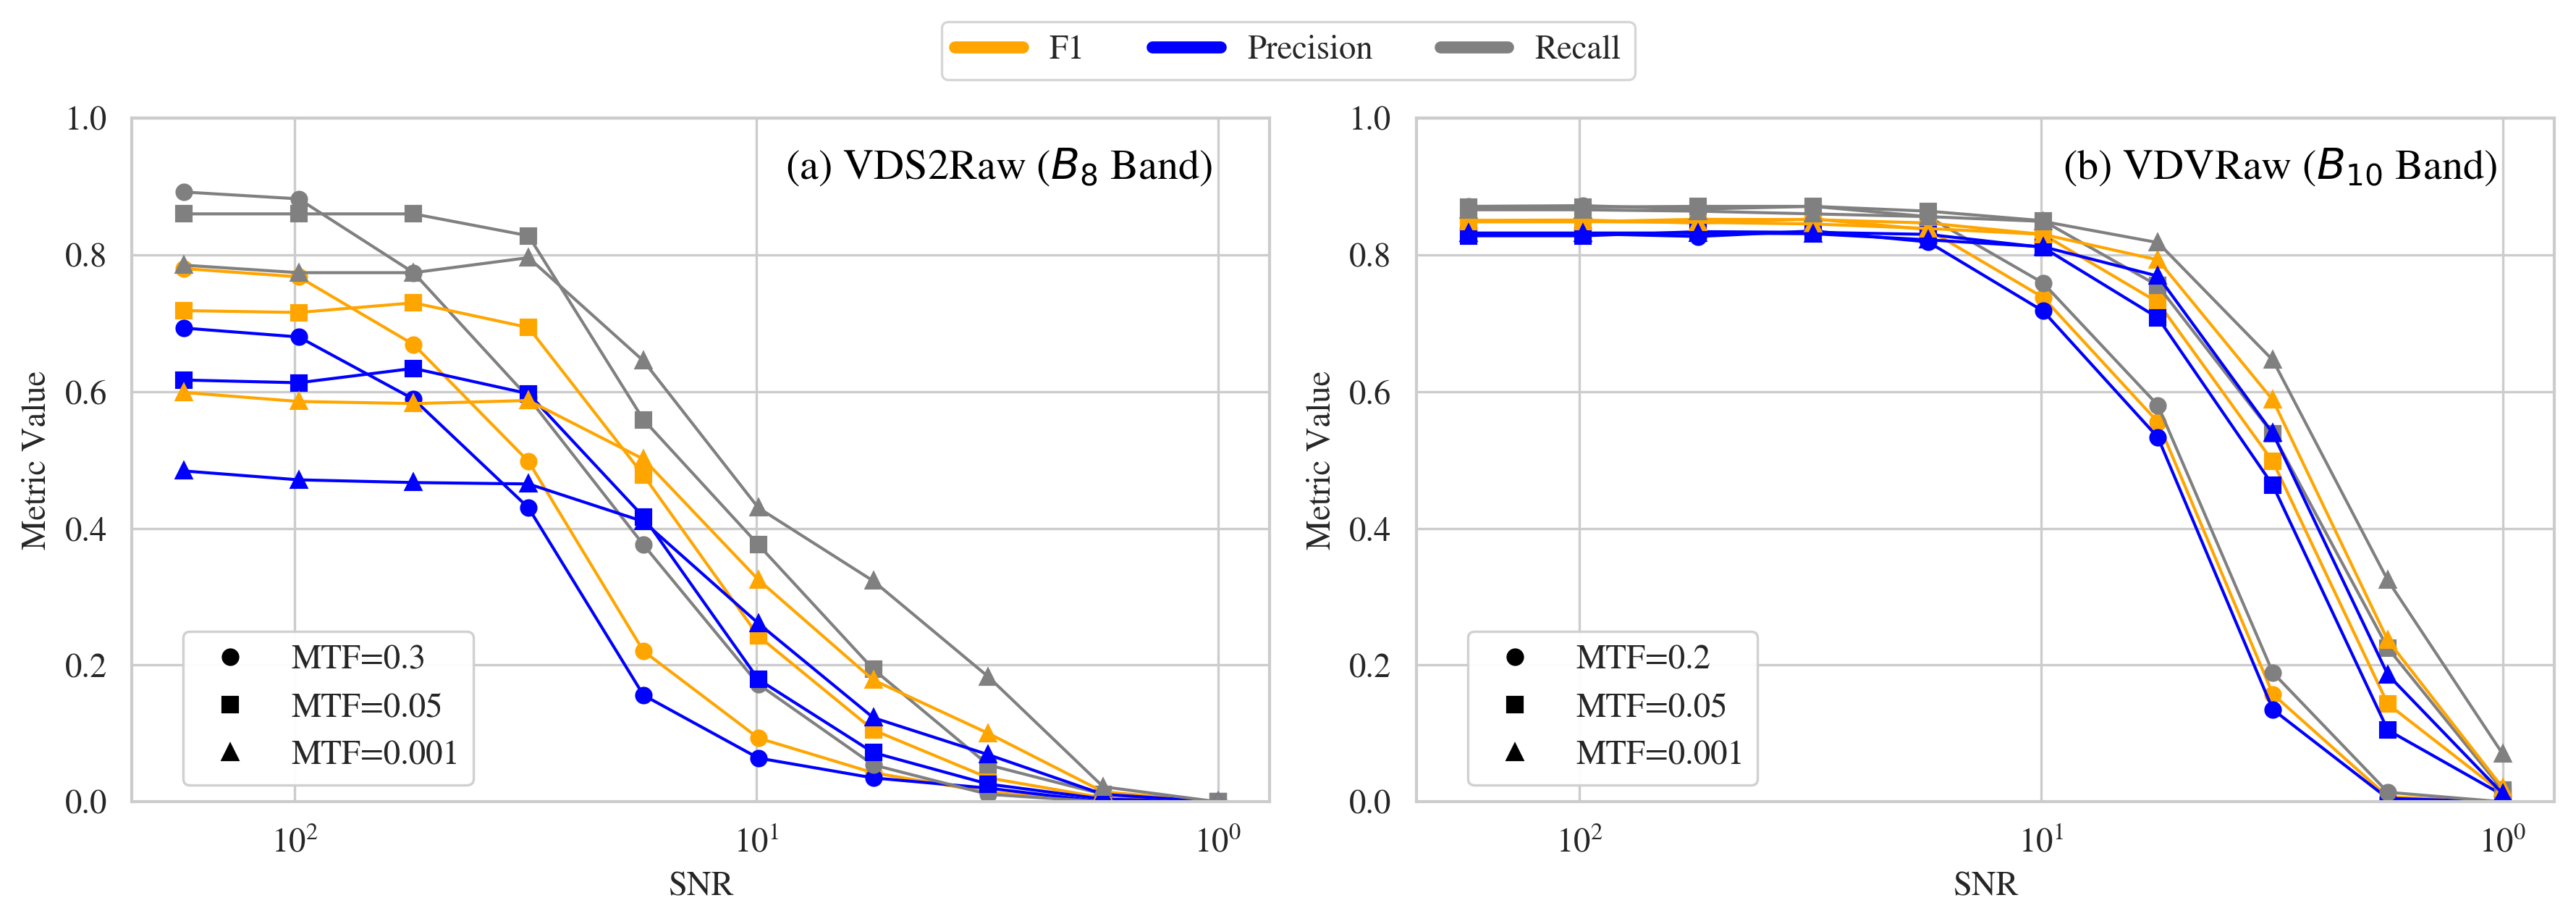

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from style import set_style
set_style(scale_factor=.7)


# Read data
df_sen = pd.read_pickle('/Data_large/marine/PythonProjects/MMDET/studies/degradationStudy/sentinel_SNR_study_b8.pkl')
df_ven = pd.read_pickle('/Data_large/marine/PythonProjects/MMDET/studies/degradationStudy/venus_SNR_study_b10.pkl')

# Prepare colors and markers
metrics = ['F1', 'Precision', 'Recall']
colors = {'F1': 'orange', 'Precision': 'blue', 'Recall': 'gray'}

# Create subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 4), dpi=300)

# List of dataframes and titles for iteration
dataframes = [df_sen, df_ven]
titles = ['(a) VDS2Raw ($B_8$ Band)', '(b) VDVRaw ($B_{10}$ Band)']

for ax, df, title in zip(axes, dataframes, titles):
    # Get unique MTF values and assign markers
    mtf_values = df['MTF'].unique()
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*']  # Add more markers if needed
    mtf_to_marker = dict(zip(mtf_values, markers))
    
    # Plot data
    for mtf in mtf_values:
        subset = df[df['MTF'] == mtf]
        for metric in metrics:
            ax.plot(subset['SNR'], subset[metric],
                    color=colors[metric],
                    marker=mtf_to_marker[mtf],
                    linestyle='-',
                    linewidth=1,
                    label=None)
    
    # Set plot properties
    ax.set_xlabel('SNR')
    ax.set_ylabel('Metric Value')
    ax.set_xscale('log')
    ax.set_ylim(0, 1)
    ax.invert_xaxis()
    ax.grid(True)
    ax.set_title(title, loc='right', pad=-20, fontsize=14, color='black', x=0.95)
    
    # Create legend handles for MTF values (markers)
    mtf_legend_handles = [Line2D([0], [0], color='black', marker=mtf_to_marker[mtf], linestyle='None') for mtf in mtf_values]
    mtf_legend_labels = [f'MTF={mtf}' for mtf in mtf_values]
    
    # Add MTF legend to each subplot
    legend2 = ax.legend(handles=mtf_legend_handles, labels=mtf_legend_labels, title='', loc='lower left', bbox_to_anchor=(0.03, 0))
    ax.add_artist(legend2)

# Create legend handles for metrics (colors)
metric_legend_handles = [Line2D([0], [0], color=colors[metric], lw=4) for metric in metrics]
metric_legend_labels = metrics

# Add Metrics legend to the figure
fig.legend(handles=metric_legend_handles, labels=metric_legend_labels, title='', loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.075))

plt.tight_layout()
plt.savefig('/Data_large/marine/PythonProjects/MMDET/plots/Fig13_SNR_study.png', dpi=500, bbox_inches='tight')
plt.show()